In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import io
import tarfile
import gzip
from pathlib import Path
from tqdm import tqdm
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df_path = Path('../data/feat_matrix/Manipulate-Image-Features.pkl')
archive_path = df_path.with_name(df_path.stem + '.tar.gz')

if not os.path.exists(archive_path):
    with tarfile.open(archive_path, 'w:gz') as tar:
        tar.add(df_path, arcname=df_path.name)
else:
    with tarfile.open(archive_path, 'r:gz') as tar:
        pkl_members = [m for m in tar.getmembers()
                       if m.name.endswith('.pkl') and m.isfile()]
        
        if not pkl_members:
            raise ValueError('No .pkl file found in archive')
        
        member = pkl_members[0]
        print(f'Extracting: {member.name!r} size={member.size} bytes')

        if member.size == 0:
            raise ValueError('Pkl member has 0 bytes -- archive is corrupt, delete and re-run')
        
        f = tar.extractfile(member)
        if f is None:
            raise ValueError('Could not extract .pkl file')
            
        data = f.read()

    if data[:2] == b'\x1f\x8b':
        data = gzip.decompress(data)

    df = pickle.loads(data)

    if not isinstance(df, pd.DataFrame):
        raise TypeError(f'Expected DataFrame, got {type(df)}')

Extracting: 'Manipulate-Image-Features.pkl' size=7694127320 bytes


In [3]:
df_sample = df[:5000000]
df_sample.head(5)

,image_id,label,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,...,feat_80,feat_81,feat_82,feat_83,feat_84,feat_85,feat_86,feat_87,feat_88,feat_89
0,0,0,0.606445,0.001953,0.0,0.0,0.0,0.0,0.0,0.0,...,0.064453,0.263672,1.727823,0.852311,0.168868,0.581885,0.691629,-0.247261,0.835812,0.853667
1,0,0,0.634766,0.001953,0.0,0.0,0.0,0.0,0.0,0.0,...,0.071289,0.261719,1.480847,0.845447,0.198830,0.624428,2.182204,-0.517785,0.817380,0.832598
2,0,0,0.635742,0.001953,0.0,0.0,0.0,0.0,0.0,0.0,...,0.061523,0.257812,1.843750,0.891489,0.178098,0.617363,3.087025,-0.062009,0.867658,0.894150
3,0,0,0.609375,0.001953,0.0,0.0,0.0,0.0,0.0,0.0,...,0.055664,0.244141,2.644153,0.841295,0.151001,0.560503,2.269908,-0.053270,0.814864,0.895385
4,0,0,0.616211,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.072266,0.256836,2.305444,0.842433,0.156008,0.552632,2.916367,-0.637114,0.826557,0.880141


In [4]:
def image_fingerprint(
        df: pd.DataFrame,
        non_pca_cols: np.ndarray,
        image_id: str='image_id',
        label_col: str='label'
    ):
    
    X = df.drop(non_pca_cols, axis=1)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca = PCA(n_components=70)
    X_pca = pca.fit_transform(X_scaled)
    df_pca = pd.DataFrame(X_pca, columns=[f'feat_{x}' for x in np.arange(70)])
    for i, cols in enumerate(non_pca_cols):
        df_pca.insert(i, cols, df[cols])
    
    feat_cols = df_pca.filter(like='feat_').columns
    C = df_pca.groupby(image_id).size()
    C = pd.DataFrame(C, columns=['Count'])
    D = df_pca.groupby(image_id)[label_col].sum() / C['Count']
    D = pd.DataFrame(D, columns=['Density'])
    F = df_pca.groupby(image_id)[feat_cols].mean()
    df_cluster = pd.concat([C, D, F], axis=1)
    
    return df_cluster.reset_index()

**Elbow Method --> n_clusters=5**

In [5]:
df_cluster = image_fingerprint(df_sample, non_pca_cols=['image_id', 'label'])

In [6]:
df_cluster

,image_id,Count,Density,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,...,feat_60,feat_61,feat_62,feat_63,feat_64,feat_65,feat_66,feat_67,feat_68,feat_69
0,0,4599,0.000000,0.022806,1.777351,-0.528019,1.342575,-0.399107,0.223502,-0.182481,...,0.038043,0.030229,0.056955,0.013840,-0.059325,0.045635,0.039320,-0.036638,-0.017882,0.064316
1,1,7735,0.013963,3.524243,-2.395758,-2.804047,0.488135,-0.969905,-0.182599,0.520259,...,-0.001150,-0.044790,-0.169637,-0.140819,-0.045691,0.066962,-0.118132,-0.074438,0.049544,0.097577
2,2,2961,0.000000,1.869540,-1.335248,-0.893111,-0.479822,-0.019176,-0.215278,0.338366,...,0.008419,-0.075724,0.035654,-0.030462,0.012360,0.017177,-0.050302,0.036449,0.004315,-0.020439
3,3,2961,0.101317,1.058627,-0.881274,-0.715956,-0.621049,0.148178,-0.214802,0.349310,...,0.005840,-0.073068,0.045883,-0.032818,0.011344,0.018691,-0.039269,0.004409,0.001402,-0.029442
4,4,2961,0.026005,1.712673,-1.291339,-0.962954,-0.489960,-0.022205,-0.154471,0.386373,...,-0.017351,-0.055842,0.019325,-0.031073,0.015479,0.015812,-0.032149,0.049548,0.006170,-0.022072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,1243,1457,0.036376,-4.287612,1.054613,-0.365165,-1.445573,0.726474,-0.008110,0.334992,...,-0.002882,0.018968,-0.027490,0.052178,0.046076,0.018395,0.041710,-0.037037,-0.015944,-0.005524
1244,1244,2583,0.101432,-0.984924,1.786644,1.336983,-0.235409,0.742541,0.195247,-0.293120,...,0.010198,-0.048368,-0.042246,-0.052528,0.035290,-0.035889,-0.073438,-0.002181,-0.008206,-0.058481
1245,1245,10353,0.092437,0.733083,1.829934,0.454005,1.060033,-0.108537,-0.085021,-0.508504,...,0.020028,-0.000121,-0.021019,0.002036,-0.054077,0.008870,0.000605,0.026933,-0.001343,0.012132
1246,1246,2583,0.070074,-1.155451,1.622832,1.201961,-0.384597,0.890614,0.370002,-0.271847,...,0.003968,-0.063088,-0.034843,-0.069601,0.031488,-0.026531,-0.076287,-0.019342,0.001439,-0.048115


In [24]:
df_cluster = image_fingerprint(df_sample, non_pca_cols=['image_id', 'label'])
X_cluster = df_cluster.iloc[:, 1:].to_numpy()
kmeans = KMeans(n_clusters=5, random_state=21)
clusters = kmeans.fit_predict(X_cluster)

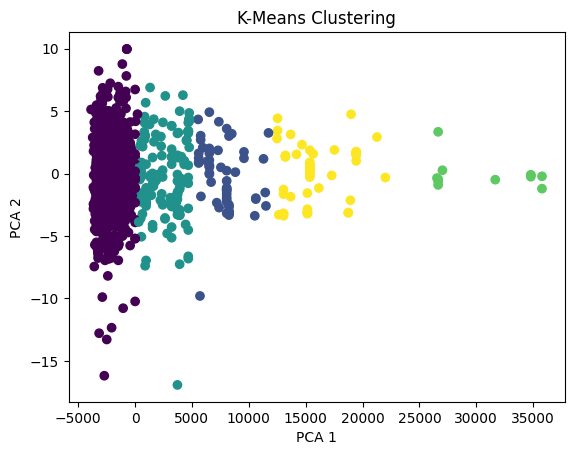

In [25]:
plot_pca = PCA(n_components=2)
X_plot = plot_pca.fit_transform(X_cluster)

plt.scatter(X_plot[:, 0], X_plot[:, 1], c=clusters)
# plt.scatter(X_cluster[:, 0], X_cluster[:, 1], c=clusters)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clustering')
plt.show()

In [ ]:
def train_test_split(
        df: pd.DataFrame,
        cluster: np.ndarray,
        test_size: np.float32=0.2,
        random_state: np.int64=None,
        image_id: str='image_id'
    ):
    
    df_split = pd.concat([df[image_id], pd.DataFrame(cluster, columns=['cluster_id'])], axis=1)
    df_split['train?'] = np.zeros((len(df_split)), dtype=np.int8)
    
    for i in range(df_split['cluster_id'].nunique()):
        train_idx = df_split[df_split['cluster_id'] == i][image_id].sample(frac=1-test_size, random_state=random_state)
        df_split.loc[train_idx, 'train?'] = 1

    train_idx = df_split[image_id][df_split['train?'] == 1].to_numpy()
    test_idx = df_split[image_id][df_split['train?'] == 0].to_numpy()

    return train_idx, test_idx

In [ ]:
def train_test_split(df: pd.DataFrame, test_size:float = 0.2): # -> tuple(list, list)
    # Convert df to df_cluster
    df_cluster = image_fingerprint(df)
    X_cluster = df_cluster.to_numpy()
    kmeans = KMeans(n_clusters=5)
    clusters = kmeans.fit_predict(X_cluster)

    df_split = pd.concat([df_cluster, pd.DataFrame(clusters, columns =['cluster_id'])], axis=1)
    df_split = df_split.loc[:, ['image_id', 'cluster_id']]
    df_split['train?'] = np.zeros((len(df_split)), dtype=np.int8)

    for i in range(df_split['cluster_id'].nunique()):
        train_ids = df_split[df_split['cluster_id'] == i]['image_id'].sample(frac=1-test_size, random_state=21)
        df_split.loc[train_ids, 'train?'] = 1
    train_idx = df_split['image_id'][df_split['train?']==1].to_numpy()
    test_idx = df_split['image_id'][df_split['train?']==0].to_numpy()
    features = [fea for fea in df.columns if fea not in ['label', 'image_id']]
    # Train
    train_data = df[df['image_id'].isin(train_idx)]
    X_train = train_data[features].values
    y_train = train_data['label'].values
    # Test
    test_data = df[df['image_id'].isin(test_idx)]
    X_test = test_data[features].values
    y_test = test_data['label'].values

    return X_train, X_test, y_train, y_test

In [37]:
train_idx, test_idx = train_test_split(df=df_cluster, cluster=clusters, frac=0.8, random_state=21)
len(train_idx) / (len(train_idx) + len(test_idx))

0.8012820512820513